In [1]:
import copy
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

In [2]:
DATA_FOLDER = "../data"
COLORADO_DATA_FOLDER = os.path.join(DATA_FOLDER,"Colorado_Data")
COLORADO_DF_PATH = os.path.join(COLORADO_DATA_FOLDER,"Colorado_Outbreak_Data_2021-09-01.csv")
MASTER_FIPS_PATH = os.path.join(COLORADO_DATA_FOLDER,"county_fips_master.csv")

In [3]:
colorado_outbreaks = pd.read_csv("../data/colorado_outbreaks.csv")
colorado_outbreaks["Date Reported"] = pd.to_datetime(colorado_outbreaks["Date Reported"])
colorado_outbreaks["Date Resolved"] = pd.to_datetime(colorado_outbreaks["Date Resolved"])
colorado_outbreaks["Duration"] = (colorado_outbreaks["Date Resolved"] - colorado_outbreaks["Date Reported"]).dt.days
colorado_outbreaks

,Setting name,Date Resolved,County,Date Reported,Total cases,Total deaths,fips,Duration
0,"Fairacres Manor, Inc. (020369): March 2020",2020-05-18,Weld,2020-03-17,86,13,8123,62
1,Centennial Health Care Center (020317): March ...,2020-06-01,Weld,2020-03-20,88,22,8123,73
2,Mountain States Rosen Company,2020-05-27,Weld,2020-03-31,9,0,8123,57
3,Aurora Organic Dairy - Platteville,2020-05-12,Weld,2020-04-01,7,1,8123,41
4,Weld County Jail: April 2020,2021-04-01,Weld,2020-04-01,116,1,8123,365
...,...,...,...,...,...,...,...,...
8918,Pearl Assisted Living (23A936),2022-08-02,Elbert,2022-07-15,9,0,8039,18
8919,Good Samaritan Society- Simla (020597): August...,2022-09-02,Elbert,2022-08-04,11,0,8039,29
8920,Good Samaritan Society- Simla (020597): Octobe...,2022-11-11,Elbert,2022-10-17,8,0,8039,25
8921,Good Samaritan Society- Simla (020597): Januar...,2023-02-21,Elbert,2023-01-30,11,0,8039,22


In [4]:
# Create a new dataframe with a DatetimeIndex for every day in the range of your data
dates = pd.date_range(colorado_outbreaks["Date Reported"].min(), colorado_outbreaks["Date Resolved"].max(), freq="D")
index = pd.MultiIndex.from_product([colorado_outbreaks["fips"].unique(), dates], names=["fips", "datetime"])
active_outbreaks = pd.DataFrame(index=index, columns=["active_outbreaks"])

# Iterate over each FIPS code and each day in the range, counting the number of active outbreaks
for fips in colorado_outbreaks["fips"].unique():
    for date in dates:
        num_active = ((colorado_outbreaks["fips"] == fips) & (colorado_outbreaks["Date Reported"] <= date) & (colorado_outbreaks["Date Resolved"] > date)).sum()
        active_outbreaks.loc[(fips, date), "active_outbreaks"] = num_active
# Reshape the dataframe so that each FIPS code is a column and the index is datetime
active_outbreaks = active_outbreaks.reset_index().pivot(index="datetime", columns="fips", values="active_outbreaks")
active_outbreaks = active_outbreaks.astype(float).fillna(0)

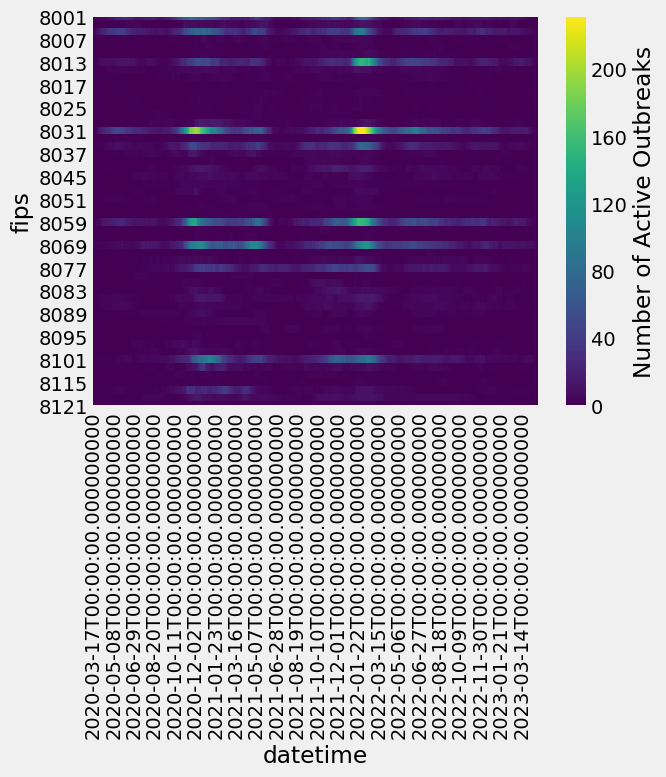

In [5]:
# Create the matrix plot using heatmap
sns.heatmap(active_outbreaks.T, cmap="viridis", cbar_kws={"label": "Number of Active Outbreaks"})


In [6]:
# Create a Series of all the values in the active_outbreaks dataframe
values = active_outbreaks.stack()

# Use loc[] to select only the NaN values
nan_values = values.loc[values.isna()]

# Print the locations of all the NaN values
print(nan_values.index)

MultiIndex([], names=['datetime', 'fips'])


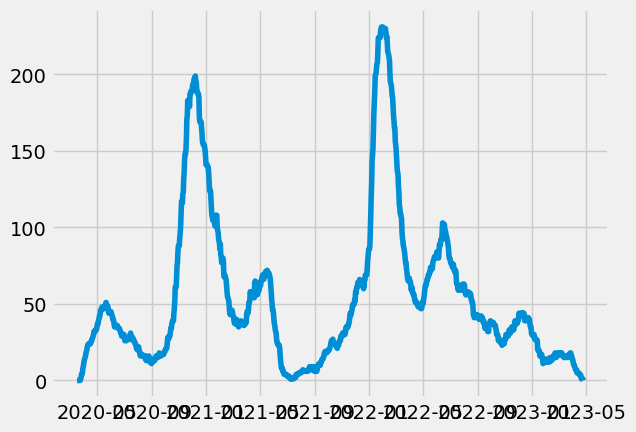

In [7]:
plt.plot(active_outbreaks[8031])

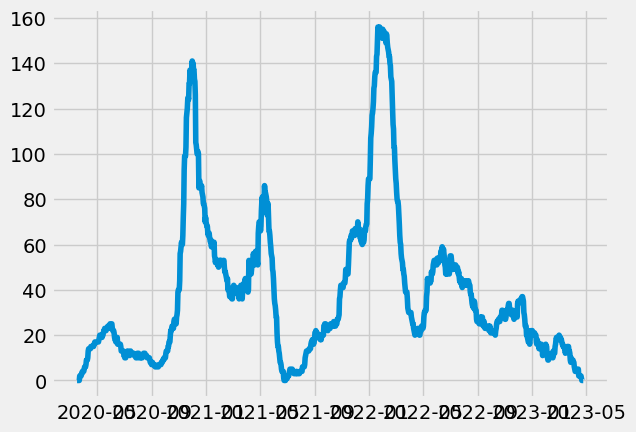

In [8]:
plt.plot(active_outbreaks[8059])

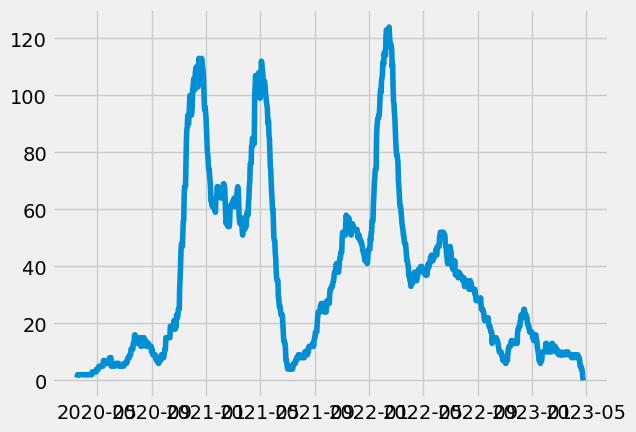

In [9]:
plt.plot(active_outbreaks[8069])

In [10]:
panel_active_outbreaks = pd.melt(active_outbreaks.reset_index(), id_vars=[ "datetime"], value_name="active_outbreaks")

In [11]:
panel_active_outbreaks

,datetime,fips,active_outbreaks
0,2020-03-17,8001,0.0
1,2020-03-18,8001,0.0
2,2020-03-19,8001,0.0
3,2020-03-20,8001,0.0
4,2020-03-21,8001,0.0
...,...,...,...
61285,2023-04-21,8125,0.0
61286,2023-04-22,8125,0.0
61287,2023-04-23,8125,0.0
61288,2023-04-24,8125,0.0


In [12]:
summary_stats = panel_active_outbreaks.groupby("fips").describe()
summary_stats

active_outbreaks                                                    
                count       mean        std  min   25%   50%   75%    max
fips                                                                     
8001           1135.0  23.132159  19.200928  0.0  11.0  17.0  28.0   84.0
8003           1135.0   3.233480   3.006039  0.0   0.5   3.0   5.0   13.0
8005           1135.0  28.728634  19.717682  0.0  14.0  24.0  38.0  102.0
8007           1135.0   1.050220   1.367337  0.0   0.0   1.0   2.0    7.0
8009           1135.0   0.407930   0.727471  0.0   0.0   0.0   1.0    3.0
8011           1135.0   0.699559   1.248120  0.0   0.0   0.0   1.0    7.0
8013           1135.0  25.472247  28.947969  0.0   8.0  18.0  31.0  152.0
8014           1135.0   2.408811   2.197544  0.0   1.0   2.0   3.0   11.0
8015           1135.0   1.079295   0.993304  0.0   0.0   1.0   2.0    4.0
8017           1135.0   0.118943   0.323864  0.0   0.0   0.0   0.0    1.0
8021           1135.0   0.577974   0.806089  0.0   0.0   0.0   1.0    3.0
8023           1135.0   0.268722   0.488889  0.0   0.0   0.0   0.0    2.0
8025           1135.0   0.411454   0.667229  0.0   0.0   0.0   1.0    3.0
8027           1135.0   0.307489   0.530952  0.0   0.0   0.0   1.0    2.0
8029           1135.0   2.903965   4.051970  0.0   0.0   1.0   3.0   19.0
8031           1135.0  54.788546  51.622675  0.0  19.0  39.0  67.0  231.0
8033           1135.0   0.087225   0.303368  0.0   0.0   0.0   0.0    2.0
8035           1135.0  17.897797  15.658000  0.0   6.0  14.0  26.5   79.0
8037           1135.0   2.254626   2.564411  0.0   0.0   2.0   3.0   16.0
8039           1135.0   0.598238   1.113805  0.0   0.0   0.0   1.0    4.0
8043           1135.0   4.682819   5.399214  0.0   1.0   3.0   6.0   21.0
8045           1135.0   2.741850   2.316523  0.0   1.0   2.0   4.0   11.0
8047           1135.0   0.948899   0.888411  0.0   0.0   1.0   1.0    3.0
8049           1135.0   0.952423   1.630678  0.0   0.0   0.0   1.0   11.0
8051           1135.0   0.755066   0.872825  0.0   0.0   1.0   1.0    3.0
8055           1135.0   0.525110   0.837310  0.0   0.0   0.0   1.0    3.0
8057           1135.0   0.138326   0.345394  0.0   0.0   0.0   0.0    1.0
8059           1135.0  38.681938  34.164094  0.0  15.0  27.0  52.0  156.0
8061           1135.0   0.192070   0.521266  0.0   0.0   0.0   0.0    2.0
8065           1135.0   0.290749   0.635552  0.0   0.0   0.0   0.0    3.0
8069           1135.0  36.248458  31.154985  0.0  10.0  27.0  53.0  124.0
8073           1135.0   0.219383   0.531523  0.0   0.0   0.0   0.0    3.0
8075           1135.0   2.355947   2.279461  0.0   1.0   2.0   4.0   11.0
8077           1135.0  16.369163  14.394674  0.0   4.0  14.0  25.0   56.0
8079           1135.0   0.288106   0.681572  0.0   0.0   0.0   0.0    3.0
8081           1135.0   1.015859   1.910178  0.0   0.0   0.0   1.0    9.0
8083           1135.0   2.503084   3.280230  0.0   0.0   1.0   3.5   15.0
8085           1135.0   4.081938   4.203528  0.0   1.0   3.0   5.0   17.0
8087           1135.0   2.574449   2.415313  0.0   1.0   2.0   4.0   13.0
8089           1135.0   1.406167   1.645837  0.0   0.0   1.0   2.0    8.0
8091           1135.0   0.644053   1.284900  0.0   0.0   0.0   0.0    4.0
8093           1135.0   0.565639   0.965389  0.0   0.0   0.0   1.0    3.0
8095           1135.0   0.130396   0.403579  0.0   0.0   0.0   0.0    2.0
8097           1135.0   0.837004   1.291966  0.0   0.0   0.0   1.0    8.0
8099           1135.0   1.246696   1.761064  0.0   0.0   1.0   2.0   10.0
8101           1135.0  24.818502  26.285447  0.0   6.0  15.0  34.0  104.0
8107           1135.0   3.809692   5.277560  0.0   1.0   2.0   5.0   36.0
8109           1135.0   0.422907   0.684294  0.0   0.0   0.0   1.0    2.0
8115           1135.0   0.308370   0.550829  0.0   0.0   0.0   1.0    2.0
8117           1135.0   6.050220   9.109279  0.0   1.0   2.0   6.0   40.0
8119           1135.0   4.047577   3.541569  0.0   1.0   3.0   7.0   14.0
8121     

### Number of Investigations Opened At Every Datetime

In [13]:
outbreak_counts = colorado_outbreaks.groupby("Date Reported").size().reset_index(name="num_outbreaks")
outbreak_counts

,Date Reported,num_outbreaks
0,2020-03-17,2
1,2020-03-18,2
2,2020-03-19,1
3,2020-03-20,2
4,2020-03-23,4
...,...,...
884,2023-04-04,3
885,2023-04-10,2
886,2023-04-11,1
887,2023-04-12,2


In [14]:
outbreak_counts.describe()

,num_outbreaks
count,889.000000
mean,10.037120
std,10.620065
min,1.000000
25%,3.000000
50%,6.000000
75%,13.000000
max,78.000000


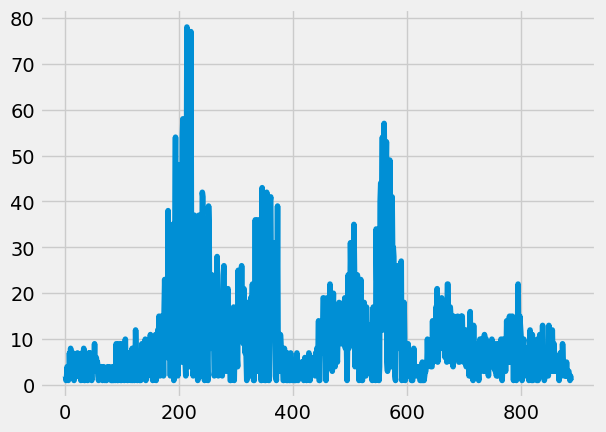

In [15]:
plt.plot(outbreak_counts["num_outbreaks"])

### Number of Investigations Active At Every Datetime

In [16]:
active_investigations = active_outbreaks.T.sum(axis=0)
active_investigations.describe()

count    1135.000000
mean      344.074890
std       280.906395
min         0.000000
25%       131.000000
50%       248.000000
75%       456.500000
max      1281.000000
dtype: float64

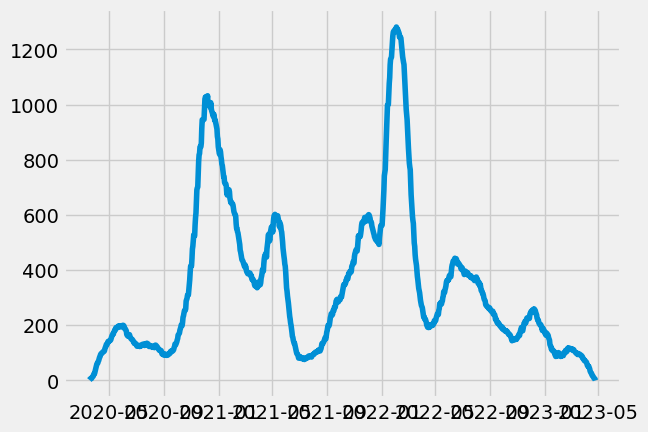

In [17]:
plt.plot(active_investigations)

### Duration of Each Investigation?

In [18]:
durations_statistics = colorado_outbreaks.groupby("fips")["Duration"].describe()

In [19]:
durations_statistics

,count,mean,std,min,25%,50%,75%,max
fips,,,,,,,,
8001,581.0,45.072289,51.786447,-22.0,21.00,29.0,49.00,590.0
8003,104.0,34.423077,30.260260,-31.0,21.00,29.0,37.25,189.0
8005,925.0,35.103784,36.143773,-36.0,17.00,26.0,41.00,447.0
8007,40.0,29.750000,22.186563,-2.0,16.75,25.0,37.00,112.0
8009,18.0,25.722222,13.069072,2.0,16.25,25.5,32.00,51.0
8011,18.0,44.111111,27.689218,8.0,25.50,36.0,57.75,111.0
8013,643.0,44.534992,40.120728,-81.0,21.00,33.0,58.00,286.0
8014,56.0,48.821429,45.143854,5.0,23.00,35.0,55.25,280.0
8015,32.0,38.281250,50.065270,13.0,22.00,26.0,32.50,302.0


In [20]:
colorado_outbreaks[colorado_outbreaks["Date Resolved"] < colorado_outbreaks["Date Reported"]]

,Setting name,Date Resolved,County,Date Reported,Total cases,Total deaths,fips,Duration
18,Victory Outreach Transitional Housing,2020-05-29,Weld,2020-06-12,12,0,8123,-14
218,The Greeley Stampede,2021-07-12,Weld,2021-07-13,25,0,8123,-1
285,Windsong at Northridge (23K987): November 2021,2021-11-30,Weld,2021-12-09,6,3,8123,-9
292,University of Northern Colorado Men's Basketba...,2021-11-22,Weld,2021-12-27,5,0,8123,-35
335,Erie Middle School: January 2022,2022-03-16,Weld,2022-03-17,35,0,8123,-1
...,...,...,...,...,...,...,...,...
8732,Tiger by the Tail,2021-01-05,Montezuma,2021-01-11,2,0,8083,-6
8735,Vista Grande Inn (021213): December 2020,2021-01-11,Montezuma,2021-01-25,6,0,8083,-14
8737,Montezuma-Cortez High School: November 2020,2020-12-11,Montezuma,2021-02-02,8,0,8083,-53
8749,BeeHive Homes at the Cortez Homestead (23Z827)...,2021-08-27,Montezuma,2021-08-30,5,2,8083,-3
